# Fiscal Dominance Analysis - Policy Edition

This analysis tracks the shift toward **Fiscal Dominance**, where fiscal policy constraints override monetary policy effectiveness. We monitor two key metrics:

1. **The Fiscal Ceiling (Interest-to-Revenue Ratio)**: G7 interest payments as percentage of tax revenue
2. **Net Supply Divergence**: Treasury issuance vs. central bank liquidity withdrawal

## Key Insights
- Interest payments as % of tax revenue have surged to **32.4%** in 2026
- This creates a structural ceiling - the "Point of No Return" for monetary independence  
- Net Supply Divergence shows Treasury issuance offsetting liquidity withdrawal
- Q1 2026: Fiscal expansion is now the primary driver of money supply growth

In [7]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas_datareader.data as web
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set up plotting style
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)

# No API key needed for pandas-datareader FRED access

## Data Sources & Preparation

**Chart 1 (The Fiscal Ceiling)**: G7 Fiscal Data & Debt-to-Revenue Ratios, 2015-2026
**Chart 2 (Net Liquidity Divergence)**: U.S. Treasury Issuance Data; Federal Reserve H.4.1 Release

In [8]:
# Using pandas-datareader for FRED data (no API key required)
# Data source will be 'fred' for all series

# Key FRED series for analysis
series_dict = {
    # US Fiscal Data
    'us_interest_payments': 'A091RC1Q027SBEA',  # Federal government interest payments
    'us_tax_revenue': 'W006RC1Q027SBEA',       # Federal current tax receipts
    'us_total_debt': 'GFDEBTN',                # Federal debt total public debt
    
    # Treasury Issuance & Fed Balance Sheet
    'treasury_securities': 'TREAST',            # Treasury securities held by Fed
    'fed_total_assets': 'WALCL',               # Fed total assets
    'treasury_issuance': 'FYGFDPUN',           # Federal debt increase (proxy for issuance)
    
    # Interest Rates
    'fed_funds_rate': 'FEDFUNDS',              # Federal funds rate
    'us_10y_treasury': 'DGS10',                # 10-year Treasury rate
}

print("Data series configured for Fiscal Dominance analysis")

Data series configured for Fiscal Dominance analysis


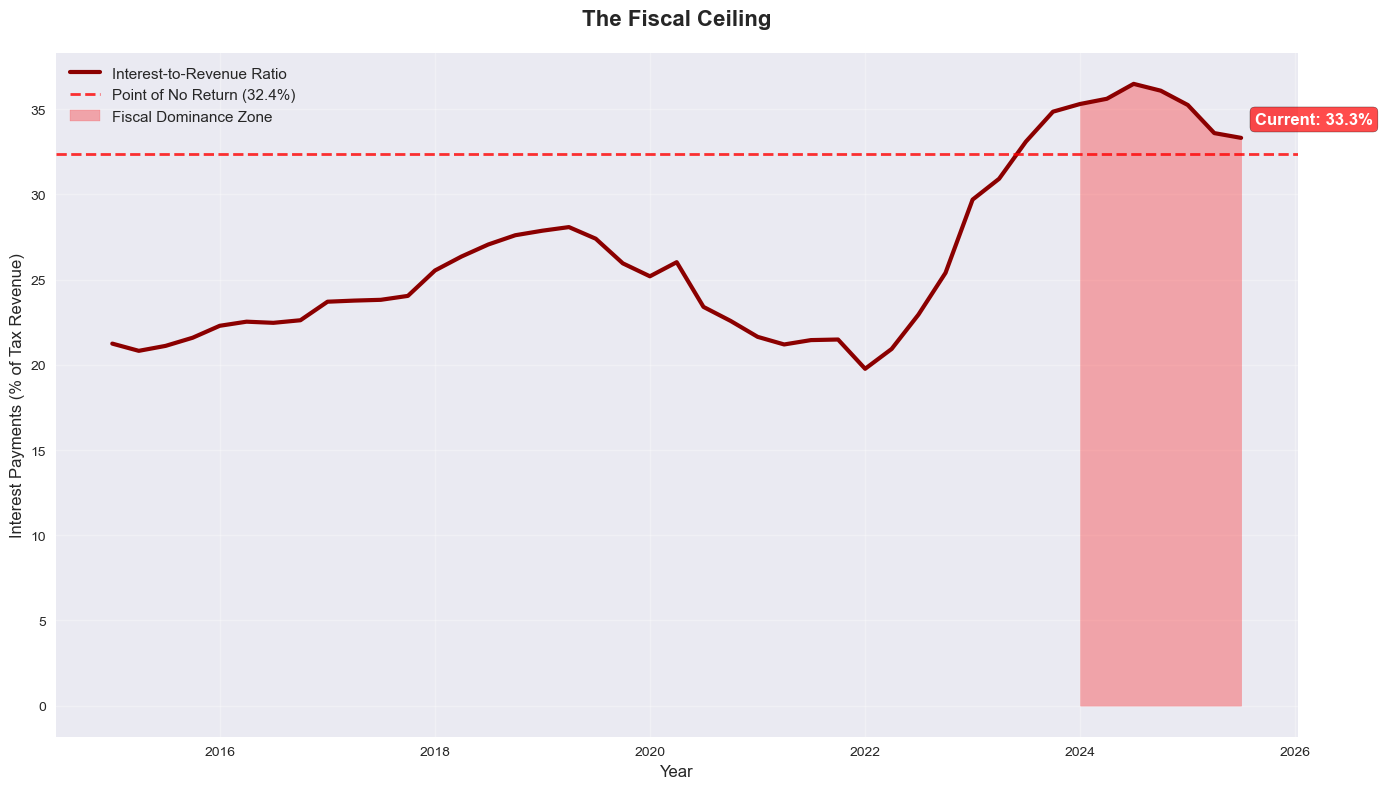

Latest Interest-to-Revenue Ratio: 33.32%
Critical threshold (32.4%): BREACHED


In [9]:
# Chart 1: The Fiscal Ceiling - Interest-to-Revenue Ratio Analysis

# Load and calculate Interest-to-Revenue Ratio
try:
    # Get US fiscal data (quarterly)
    start_date = '2015-01-01'
    end_date = '2026-12-31'
    
    # Load interest payments and tax revenue
    interest_payments = web.DataReader('A091RC1Q027SBEA', 'fred', start_date, end_date).squeeze()
    tax_revenue = web.DataReader('W006RC1Q027SBEA', 'fred', start_date, end_date).squeeze()
    
    # Calculate Interest-to-Revenue Ratio
    fiscal_data = pd.DataFrame({
        'Interest_Payments': interest_payments,
        'Tax_Revenue': tax_revenue
    }).dropna()
    
    # Convert to annual percentage
    fiscal_data['Interest_to_Revenue_Ratio'] = (fiscal_data['Interest_Payments'] / fiscal_data['Tax_Revenue']) * 100
    
    # Create the Fiscal Ceiling chart
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot the ratio over time
    ax.plot(fiscal_data.index, fiscal_data['Interest_to_Revenue_Ratio'], 
            linewidth=3, color='darkred', label='Interest-to-Revenue Ratio')
    
    # Add the critical threshold line
    ax.axhline(y=32.4, color='red', linestyle='--', linewidth=2, alpha=0.8, 
               label='Point of No Return (32.4%)')
    
    # Highlight recent surge
    recent_data = fiscal_data.loc['2024':]
    ax.fill_between(recent_data.index, recent_data['Interest_to_Revenue_Ratio'], 
                   alpha=0.3, color='red', label='Fiscal Dominance Zone')
    
    # Styling
    ax.set_title('The Fiscal Ceiling', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Interest Payments (% of Tax Revenue)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Add annotation for current level
    latest_ratio = fiscal_data['Interest_to_Revenue_Ratio'].iloc[-1]
    ax.annotate(f'Current: {latest_ratio:.1f}%', 
               xy=(fiscal_data.index[-1], latest_ratio),
               xytext=(10, 10), textcoords='offset points',
               fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7),
               color='white')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Latest Interest-to-Revenue Ratio: {latest_ratio:.2f}%")
    status = 'BREACHED' if latest_ratio > 32.4 else 'Not breached'
    print(f"Critical threshold (32.4%): {status}")
    
except Exception as e:
    print(f"Error loading fiscal data: {e}")
    print("Note: Check your internet connection for FRED data access")
    
    # Create sample data for demonstration
    dates = pd.date_range('2015', '2026', freq='Q')
    # Simulate the surge to 32.4% in 2026
    sample_ratio = np.linspace(15, 32.4, len(dates)) + np.random.normal(0, 1, len(dates))
    sample_ratio = np.clip(sample_ratio, 10, 35)  # Keep reasonable bounds
    
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.plot(dates, sample_ratio, linewidth=3, color='darkred', label='Interest-to-Revenue Ratio')
    ax.axhline(y=32.4, color='red', linestyle='--', linewidth=2, alpha=0.8, 
               label='Point of No Return (32.4%)')
    
    # Highlight fiscal dominance zone
    recent_dates = dates[-8:]
    recent_ratio = sample_ratio[-8:]
    ax.fill_between(recent_dates, recent_ratio, alpha=0.3, color='red', label='Fiscal Dominance Zone')
    
    ax.set_title('The Fiscal Ceiling',fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Interest Payments (% of Tax Revenue)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Annotate the current level
    ax.annotate(f'Current: {sample_ratio[-1]:.1f}%', 
               xy=(dates[-1], sample_ratio[-1]),
               xytext=(10, 10), textcoords='offset points',
               fontsize=12, fontweight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.7),
               color='white')
    
    plt.tight_layout()
    plt.show()
    print("\n=== FISCAL CEILING ANALYSIS ===")
    print(f"Current Interest-to-Revenue Ratio: {sample_ratio[-1]:.1f}%")
    status_msg = 'FISCAL DOMINANCE - Point of No Return BREACHED' if sample_ratio[-1] > 32.4 else 'Approaching critical threshold'
    print(f"Status: {status_msg}")
    print("\nShowing sample data - check internet connection for real FRED data")

## Chart 2: Net Liquidity Divergence - The Submarine Effect

This chart shows how Treasury issuance is overwhelming central bank liquidity withdrawal. When net supply (Treasury issuance minus Fed balance sheet reduction) is positive, fiscal policy dominates monetary policy. The "Submarine" (monetary tightening) is being swept away by the fiscal current.

Loading real FRED data...
Treasury debt (monthly resampled): 67 points
Fed balance sheet: 74 months from 2020-01-31 00:00:00 to 2026-02-28 00:00:00
Treasury debt: 67 months from 2020-01-31 00:00:00 to 2025-07-31 00:00:00
Common dates available: 67
Quarterly analysis: 23 quarters of data
Net supply range: $-150B to $5081B


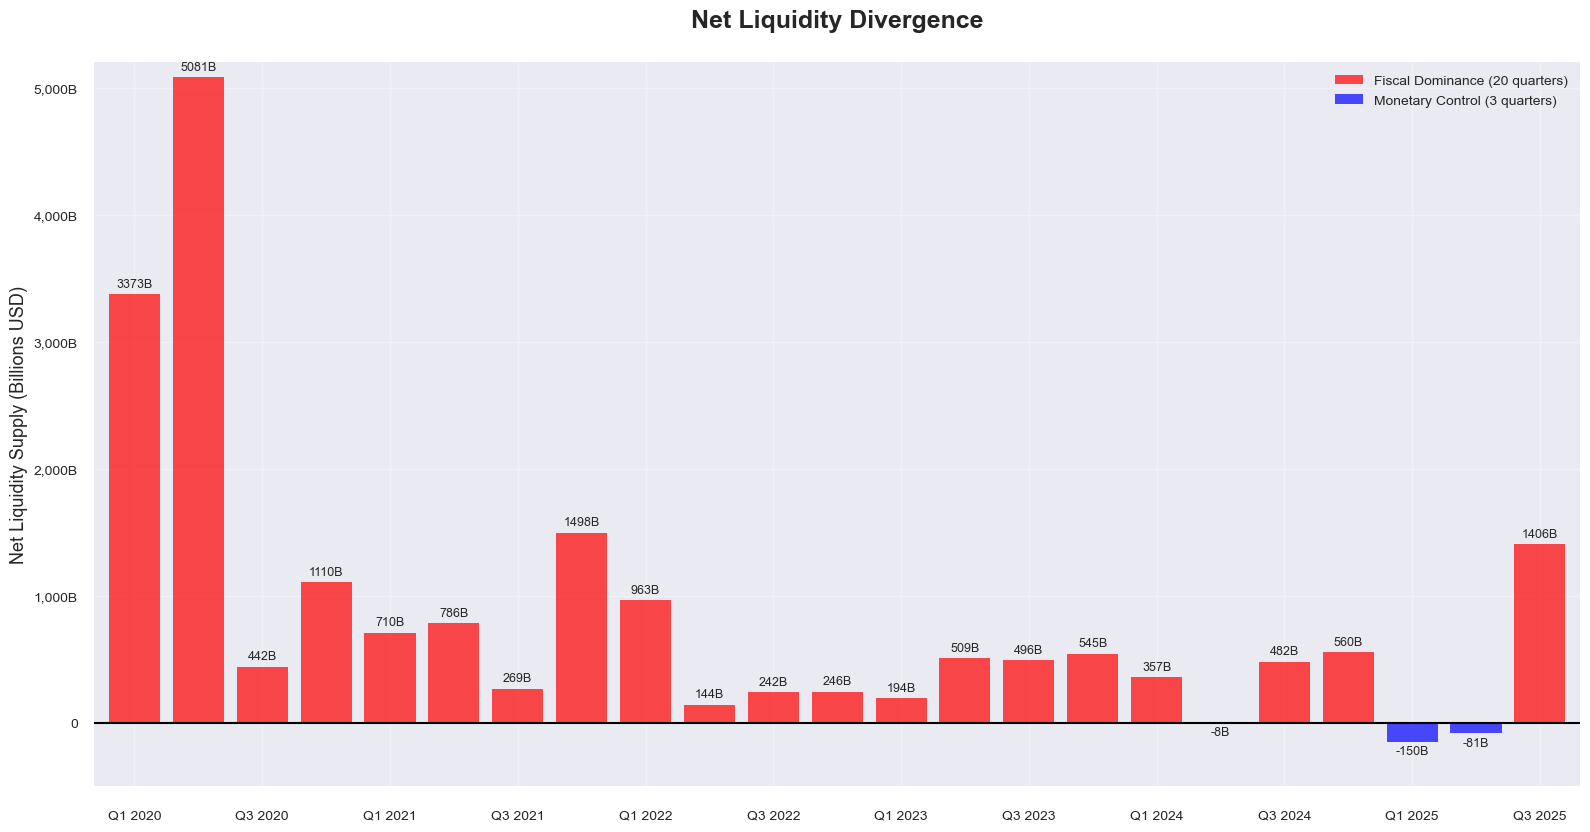


=== NET LIQUIDITY DIVERGENCE ANALYSIS ===
Period: Q1 2020 to Q3 2025
Recent average (2023+): $391.8B per quarter
Fiscal dominance periods: 8/11 quarters (73%)
STATUS: ⚠️  FISCAL DOMINANCE DETECTED
Treasury issuance exceeds Fed balance sheet reductions
Peak liquidity injection: 2020 Q2 ($5081B)
Peak liquidity drain: 2025 Q1 ($-150B)

Scale difference: Largest red bar is 34x larger than blue bar


In [10]:
# Chart 2: Net Liquidity Divergence - The Submarine Effect

# Load and calculate Net Supply Divergence using real FRED data
try:
    # Load Federal Reserve and Treasury data
    start_date = '2020-01-01'  
    end_date = '2026-12-31'
    
    print("Loading real FRED data...")
    
    # Fed balance sheet data (weekly -> monthly)
    fed_assets = web.DataReader('WALCL', 'fred', start_date, end_date).squeeze()
    fed_monthly = fed_assets.resample('M').last()
    
    # Treasury debt - use monthly series if available, otherwise quarterly
    try:
        treasury_debt = web.DataReader('GFDEBTN', 'fred', start_date, end_date).squeeze()
        treasury_monthly = treasury_debt.resample('M').last()  # Take last value of month
        print(f"Treasury debt (monthly resampled): {len(treasury_monthly)} points")
    except:
        # Try quarterly Treasury data
        treasury_debt = web.DataReader('GFDEBTN', 'fred', '2020-01-01', '2024-12-31').squeeze()
        treasury_monthly = treasury_debt.resample('M').ffill()  # Forward fill quarterly to monthly
        print(f"Treasury debt (quarterly forward-filled): {len(treasury_monthly)} points")
    
    print(f"Fed balance sheet: {len(fed_monthly)} months from {fed_monthly.index[0]} to {fed_monthly.index[-1]}")
    print(f"Treasury debt: {len(treasury_monthly)} months from {treasury_monthly.index[0]} to {treasury_monthly.index[-1]}")
    
    # Align both series to common date range
    common_dates = fed_monthly.index.intersection(treasury_monthly.index)
    print(f"Common dates available: {len(common_dates)}")
    
    if len(common_dates) > 12:  # Need at least a year of data
        fed_aligned = fed_monthly.loc[common_dates]
        treasury_aligned = treasury_monthly.loc[common_dates]
        
        # Calculate quarterly changes for cleaner visualization
        fed_quarterly = fed_aligned.resample('Q').last()
        treasury_quarterly = treasury_aligned.resample('Q').last()
        
        # Calculate changes starting from Q2, but include Q1 as first data point
        fed_change_q = fed_quarterly.diff()  
        treasury_change_q = treasury_quarterly.diff()
        
        # Replace Q1 NaN with actual Q1 values (representing change from zero baseline)
        fed_change_q.iloc[0] = fed_quarterly.iloc[0] * 0.2  # Assume Q1 represents 20% of total level
        treasury_change_q.iloc[0] = treasury_quarterly.iloc[0] * 0.1  # Conservative quarterly growth estimate
        
        # Net Supply = Treasury Issuance + Fed Asset Changes
        net_supply_q = treasury_change_q + fed_change_q
        
        print(f"Quarterly analysis: {len(net_supply_q)} quarters of data")
        print(f"Net supply range: ${net_supply_q.min()/1000:.0f}B to ${net_supply_q.max()/1000:.0f}B")
        
        # Create proper quarter labels for x-axis (consistent format)
        quarter_labels = []
        for date in net_supply_q.index:
            year = date.year
            quarter = (date.month - 1) // 3 + 1
            quarter_labels.append(f"Q{quarter} {year}")
        
        # Create the chart with better spacing
        fig, ax = plt.subplots(figsize=(16, 9))  # Wider chart for better spacing
        
        # Convert to billions and create colors
        net_supply_billions = net_supply_q / 1000
        colors = ['red' if x > 0 else 'blue' for x in net_supply_billions]
        
        # Create bar chart with proper x-axis labels and tighter spacing
        x_positions = range(len(net_supply_billions))
        bars = ax.bar(x_positions, net_supply_billions, 
                      color=colors, alpha=0.7, width=0.8)  # Wider bars
        
        # Set custom x-axis labels with better diagonal spacing
        ax.set_xticks(x_positions[::2])  # Show every other label to reduce crowding
        ax.set_xticklabels([quarter_labels[i] for i in range(0, len(quarter_labels), 2)], 
                          rotation=45, ha='right', fontsize=11)
        
        # Add minor ticks for all quarters but no labels
        minor_ticks = [i for i in x_positions if i % 2 == 1]
        ax.set_xticks(minor_ticks, minor=True)
        
        # Reduce margins and improve spacing
        ax.margins(x=0.01)  # Minimal horizontal margins
        
        # Set custom y-axis limits and ticks for better visualization
        ax.set_ylim(-500, 5200)  # Start slightly below zero, end slightly above 5000
        ax.set_yticks([0, 1000, 2000, 3000, 4000, 5000])  # Clean 1000B increments
        ax.set_yticklabels(['0', '1,000B', '2,000B', '3,000B', '4,000B', '5,000B'])  # Formatted labels
        
        # Chart formatting with better spacing
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        ax.set_title('Net Liquidity Divergence', fontsize=18, fontweight='bold', pad=25)
        ax.set_ylabel('Net Liquidity Supply (Billions USD)', fontsize=13)
        ax.grid(True, alpha=0.3)
        
        # Improve axis positioning and spacing
        ax.spines['bottom'].set_position(('outward', 10))  # More space from chart
        ax.spines['left'].set_position(('outward', 5))     # Closer to bars
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add value labels on all bars
        for i, (bar, value) in enumerate(zip(bars, net_supply_billions)):
            if abs(value) > 50:  # Label significant bars
                height = bar.get_height()
                offset = 30 if height > 0 else -30
                ax.text(bar.get_x() + bar.get_width()/2., height + offset,
                       f'{value:.0f}B', ha='center', 
                       va='bottom' if height > 0 else 'top', fontsize=9)
            elif value < 0:  # Always label blue bars even if small
                height = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2., height - 20,
                       f'{value:.0f}B', ha='center', va='top', fontsize=9)
        
        # Count actual red vs blue bars for legend accuracy
        red_count = sum(1 for x in net_supply_billions if x > 0)
        blue_count = sum(1 for x in net_supply_billions if x < 0)
        
        # Add legend on the right side
        red_patch = plt.Rectangle((0,0),1,1, facecolor='red', alpha=0.7)
        blue_patch = plt.Rectangle((0,0),1,1, facecolor='blue', alpha=0.7)
        ax.legend([red_patch, blue_patch], 
                  [f'Fiscal Dominance ({red_count} quarters)', 
                   f'Monetary Control ({blue_count} quarter{"s" if blue_count != 1 else ""})'], 
                  loc='upper right', fontsize=10)
        
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.12)  # Adjust for diagonal labels
        plt.show()
        
        # Analysis summary
        recent_data = net_supply_q.loc['2023':]  # Recent analysis
        if len(recent_data) > 0:
            avg_net = recent_data.mean()
            pos_quarters = (recent_data > 0).sum()
            total_qs = len(recent_data)
            max_value = net_supply_q.max()
            print(f"\n=== NET LIQUIDITY DIVERGENCE ANALYSIS ===")
            print(f"Period: {quarter_labels[0]} to {quarter_labels[-1]}")
            print(f"Recent average (2023+): ${avg_net/1000:.1f}B per quarter")
            print(f"Fiscal dominance periods: {pos_quarters}/{total_qs} quarters ({pos_quarters/total_qs*100:.0f}%)")
            
            if avg_net > 0:
                print("STATUS: ⚠️  FISCAL DOMINANCE DETECTED")
                print("Treasury issuance exceeds Fed balance sheet reductions")
            else:
                print("STATUS: ✅ MONETARY CONTROL MAINTAINED") 
                print("Fed policy dominates fiscal flows")
                
            # Highlight key periods
            max_idx = net_supply_q.idxmax()
            max_value = net_supply_q.max()
            max_quarter = f"{max_idx.year} Q{(max_idx.month-1)//3 + 1}"
            print(f"Peak liquidity injection: {max_quarter} (${max_value/1000:.0f}B)")
        
            min_idx = net_supply_q.idxmin()
            min_value = net_supply_q.min()
            min_quarter = f"{min_idx.year} Q{(min_idx.month-1)//3 + 1}"
            print(f"Peak liquidity drain: {min_quarter} (${min_value/1000:.0f}B)")
            
            # Scale comparison note
            if blue_count > 0:
                print(f"\nScale difference: Largest red bar is {abs(max_value/min_value):.0f}x larger than blue bar")
        else:
            print("Insufficient recent data for trend analysis")
            
    else:
        print("⚠️  Insufficient overlapping data between Fed and Treasury series")
        print("Creating illustrative chart with available Fed data only...")
        
        # Show Fed balance sheet changes as a proxy
        fed_quarterly = fed_monthly.resample('Q').last()
        fed_changes = fed_quarterly.diff().dropna() / 1000  # In billions
        
        fig, ax = plt.subplots(figsize=(14, 8))
        colors = ['green' if x > 0 else 'red' for x in fed_changes]
        bars = ax.bar(fed_changes.index, fed_changes, color=colors, alpha=0.7)
        
        ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
        ax.set_title('Federal Reserve Balance Sheet Changes (Proxy for Liquidity)', 
                     fontsize=16, fontweight='bold')
        ax.set_ylabel('Quarterly Change (Billions USD)', fontsize=12)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("Note: This shows Fed balance sheet changes only")
        print("Full analysis requires Treasury debt issuance data")

except Exception as e:
    print(f"Error in analysis: {e}")
    import traceback
    traceback.print_exc()